# Seção 1 – Análise exploratória
Histórico horário de 01/11/2025 a 30/06/2026, agregado por hora, categoria e canal.

**Convenção adotada:** `vlr_venda_desconto` é tratado como desconto concedido, de modo que
a venda bruta ≈ `receita_aprovada + vlr_venda_desconto`. Essa leitura é uma hipótese
(a base não traz dicionário detalhado) e vale para todas as métricas de "taxa de desconto".

In [1]:
import json, sys
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from src.data import carregar, serie_diaria
from src.viz import aplicar_estilo, salvar, milhoes, AZUL, LARANJA, AQUA, CINZA
aplicar_estilo()
DIAS = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
df = carregar()
df['venda_bruta'] = df.receita_aprovada + df.vlr_venda_desconto
R = {}  # números-chave reutilizados na apresentação

## 1. Qualidade dos dados

In [2]:
R['linhas'] = len(df)
R['pct_cat_corrompida_linhas'] = round(100 * df.categoria_corrompida.mean(), 1)
R['pct_cat_corrompida_receita'] = round(100 * df.loc[df.categoria_corrompida, 'receita_aprovada'].sum() / df.receita_aprovada.sum(), 1)
R['linhas_receita_nao_positiva'] = int((df.receita_aprovada <= 0).sum())
print('Nulos:', int(df.isna().sum().sum()), '| duplicatas:', int(df.duplicated().sum()))
print('Dias:', df.data.nunique(), '| horas por dia:', sorted(df.groupby('data').hora.nunique().unique()))
print(f"Categoria corrompida: {R['pct_cat_corrompida_linhas']}% das linhas, {R['pct_cat_corrompida_receita']}% da receita")
neg = df[df.receita_aprovada <= 0]
R['receita_negativa_total'] = float(neg.receita_aprovada.sum())
R['receita_negativa_pct'] = round(100 * neg.receita_aprovada.sum() / df.receita_aprovada.sum(), 1)
print(f"Receita <= 0: {len(neg)} linhas ({100*len(neg)/len(df):.1f}%), soma R$ {neg.receita_aprovada.sum():,.0f} ({R['receita_negativa_pct']}% da receita líquida)")
pos = df[df.receita_aprovada > 0]
print('Desconto por item | receita<=0: %.1f | demais: %.1f' % (neg.vlr_venda_desconto.sum() / neg.qt_material.sum(), pos.vlr_venda_desconto.sum() / pos.qt_material.sum()))
p = df.assign(neg=df.receita_aprovada <= 0).groupby('hora').neg.mean()
print(f'Linhas com receita<=0 por hora (mín / máx): {100*p.min():.1f}% / {100*p.max():.1f}%')

Nulos: 0 | duplicatas: 0
Dias: 242 | horas por dia: [np.int64(24)]
Categoria corrompida: 6.0% das linhas, 6.0% da receita
Receita <= 0: 4411 linhas (4.9%), soma R$ -21,051,829 (-4.3% da receita líquida)
Desconto por item | receita<=0: 39.0 | demais: 38.3
Linhas com receita<=0 por hora (mín / máx): 3.4% / 10.1%


**Leitura.** (i) Cerca de 6% da receita está em linhas cuja categoria é um número aleatório (falha
de ETL); como o alvo da previsão é o total diário, mantemos essas linhas e só rotulamos como
`NÃO IDENTIFICADA` nas análises por categoria. (ii) Cerca de 5% das linhas têm receita ≤ 0. A seção seguinte testa se isso se parece com estorno.

### Diagnóstico das linhas com receita ≤ 0
Se fossem estornos/cancelamentos reais, esperaríamos: (1) valores parciais e menores que as vendas; (2) relação com vendas
de dias anteriores (devolução vem depois da compra); (3) concentração em dias/horas específicos. Testamos os três.

In [3]:
pos, ng = df[df.receita_aprovada > 0], df[df.receita_aprovada < 0]
print(f"Receita < 0: {len(ng)} linhas | receita = 0: {int((df.receita_aprovada == 0).sum())} linhas")
comp = pd.DataFrame({
    '|receita| por item (mediana)': [(g.receita_aprovada / g.qt_material).abs().median() for g in (pos, ng)],
    '|receita| por pedido (mediana)': [(g.receita_aprovada / g.nr_pedidos).abs().median() for g in (pos, ng)],
    'corr(|receita|, itens)': [np.corrcoef(g.receita_aprovada.abs(), g.qt_material)[0, 1] for g in (pos, ng)],
}, index=['receita > 0', 'receita < 0']).round(2)
display(comp)
dia = df.assign(neg=df.receita_aprovada < 0).groupby('data').agg(neg=('neg', 'mean'), n=('neg', 'size'))
rec_pos = df[df.receita_aprovada > 0].groupby('data').receita_aprovada.sum()
print('Correlação da % de linhas negativas do dia com a receita positiva de L dias antes (L=0..7):',
      [round(dia.neg.corr(rec_pos.shift(l)), 2) for l in range(8)])
esp = np.sqrt(dia.neg.mean() * (1 - dia.neg.mean()) / dia.n.mean())
print(f"Desvio da % negativa entre dias: {dia.neg.std():.4f} | esperado se fosse sorteio independente (binomial): {esp:.4f}")
print('% negativa por dia da semana (seg..dom):', [round(100 * x, 1) for x in df.assign(neg=df.receita_aprovada < 0).groupby('dia_semana').neg.mean()])
R['neg_mediana_item'] = [float(x) for x in comp.iloc[:, 0]]
R['receita_abs_total'] = float(df.receita_aprovada.abs().sum())
R['receita_abs_vs_liquida_pct'] = round(100 * (R['receita_abs_total'] / df.receita_aprovada.sum() - 1), 1)
print(f"Receita líquida: R$ {df.receita_aprovada.sum()/1e6:.1f} mi | somando |receita|: R$ {R['receita_abs_total']/1e6:.1f} mi ({R['receita_abs_vs_liquida_pct']:+.1f}%)")

Receita < 0: 3513 linhas | receita = 0: 898 linhas


,|receita| por item (mediana),|receita| por pedido (mediana),"corr(|receita|, itens)"
receita > 0,49.84,75.96,0.84
receita < 0,49.66,75.60,0.85


Correlação da % de linhas negativas do dia com a receita positiva de L dias antes (L=0..7): [np.float64(0.05), np.float64(0.02), np.float64(0.03), np.float64(-0.02), np.float64(-0.06), np.float64(-0.03), np.float64(-0.02), np.float64(0.03)]
Desvio da % negativa entre dias: 0.0109 | esperado se fosse sorteio independente (binomial): 0.0101
% negativa por dia da semana (seg..dom): [3.9, 4.0, 3.7, 3.9, 4.0, 4.0, 4.0]
Receita líquida: R$ 490.3 mi | somando |receita|: R$ 532.4 mi (+8.6%)


**Conclusão do diagnóstico.** Os três testes **não** apontam para estorno: (1) o valor por item e por pedido das linhas negativas é
praticamente idêntico ao das positivas (mesma mediana, mesma relação com o nº de itens), em vez de parcial; (2) a % negativa do dia
não tem relação com as vendas dos dias anteriores; (3) a variação entre dias é a esperada para um sorteio independente de ~4% das
linhas, sem concentração em dias da semana. O padrão é compatível com **inversão de sinal** em uma pequena fração aleatória de linhas (falha de processamento), mas isso é uma
inferência: só a área dona do dado pode confirmar. Também não dá para dizer que são estornos, pois as linhas trazem itens e pedidos positivos.

**Tratamento adotado:** manter a receita como veio (líquida) como base, por ser o dado oficial, e medir a sensibilidade do
resultado ao tratamento alternativo (usar |receita|). Os níveis mudam (~+9% na receita total), mas as conclusões e o erro do modelo praticamente não mudam
(ver notebook 02). Decisão a validar com o dono do dado.

## 2. Visão macro: série diária e sazonalidade

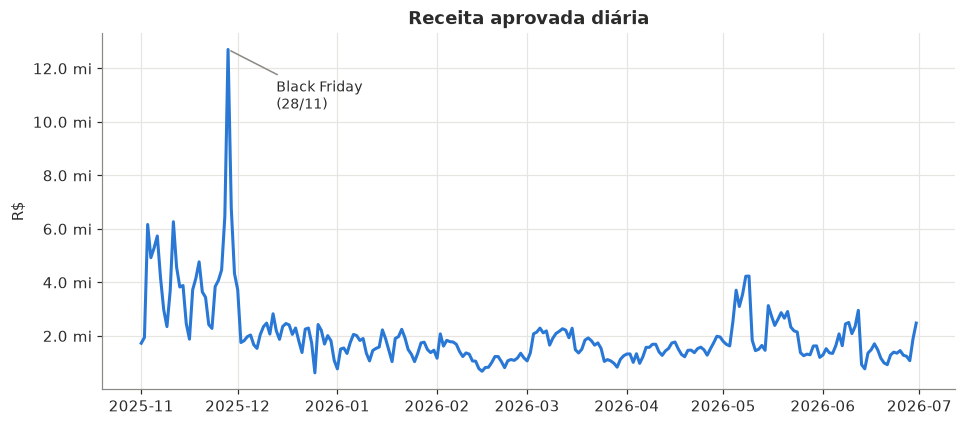

7.5 x a mediana diária na Black Friday


In [4]:
d = serie_diaria(df)
d['tx_desc'] = d.vlr_venda_desconto / (d.receita_aprovada + d.vlr_venda_desconto)
fig, ax = plt.subplots()
ax.plot(d.index, d.receita_aprovada, color=AZUL)
ax.yaxis.set_major_formatter(FuncFormatter(milhoes))
ax.set_title('Receita aprovada diária'); ax.set_ylabel('R$')
bf = pd.Timestamp('2025-11-28')
ax.annotate('Black Friday\n(28/11)', (bf, d.loc[bf, 'receita_aprovada']), xytext=(bf + pd.Timedelta(days=15), 10.5e6),
            arrowprops=dict(arrowstyle='-', color=CINZA), fontsize=9)
salvar(fig, '01_receita_diaria'); plt.show()
R['receita_total'] = float(d.receita_aprovada.sum())
R['receita_media_dia'] = float(d.receita_aprovada.mean())
R['bf_receita'] = float(d.loc[bf, 'receita_aprovada'])
R['bf_multiplo'] = round(R['bf_receita'] / d.receita_aprovada.drop(bf).median(), 1)
print(R['bf_multiplo'], 'x a mediana diária na Black Friday')

In [5]:
m = d.groupby(d.index.to_period('M')).agg(receita=('receita_aprovada', 'sum'), pedidos=('nr_pedidos', 'sum'), desc=('vlr_venda_desconto', 'sum'))
m['tx_desc_%'] = 100 * m.desc / (m.receita + m.desc)
m['ticket'] = m.receita / m.pedidos
m.round(1)

,receita,pedidos,desc,tx_desc_%,ticket
data,,,,,
2025-11,128977379.5,2195142,157366058.2,55.0,58.8
2025-12,63247272.1,788342,37996845.4,37.5,80.2
2026-01,49427420.5,582782,38167184.8,43.6,84.8
2026-02,34780181.4,447018,19725699.7,36.2,77.8
2026-03,52065163.3,668712,35728785.1,40.7,77.9
2026-04,44282126.0,533778,21355738.1,32.5,83.0
2026-05,70049966.1,793220,44009107.5,38.6,88.3
2026-06,47480317.8,511901,25417923.6,34.9,92.8


## 3. Preço médio de venda
Três ângulos: preço por item (receita/itens), ticket por pedido (receita/pedidos) e preço de tabela
implícito (venda bruta/itens). A diferença entre o último e o primeiro mostra o peso do desconto.

In [6]:
def agg(g):
    return pd.Series({
        'receita': g.receita_aprovada.sum(), 'pedidos': g.nr_pedidos.sum(), 'itens': g.qt_material.sum(),
        'preço_item': g.receita_aprovada.sum() / g.qt_material.sum(),
        'preço_tabela_item': g.venda_bruta.sum() / g.qt_material.sum(),
        'ticket': g.receita_aprovada.sum() / g.nr_pedidos.sum(),
        'itens_por_pedido': g.qt_material.sum() / g.nr_pedidos.sum(),
        'tx_desc_%': 100 * g.vlr_venda_desconto.sum() / g.venda_bruta.sum(),
    })
por_cat = df.groupby('categoria').apply(agg, include_groups=False).sort_values('receita', ascending=False)
por_canal = df.groupby('canal').apply(agg, include_groups=False)
R['preco_item_geral'] = float(df.receita_aprovada.sum() / df.qt_material.sum())
R['ticket_geral'] = float(df.receita_aprovada.sum() / df.nr_pedidos.sum())
R['tx_desc_geral'] = float(100 * df.vlr_venda_desconto.sum() / df.venda_bruta.sum())
R['canal_receita_pct'] = (100 * por_canal.receita / por_canal.receita.sum()).round(1).to_dict()
R['canal_ticket'] = por_canal.ticket.round(1).to_dict()
display(por_canal.round(2)); display(por_cat.round(2))

,receita,pedidos,itens,preço_item,preço_tabela_item,ticket,itens_por_pedido,tx_desc_%
canal,,,,,,,,
App,3.734734e+08,5088139.0,7727618.0,48.33,87.55,73.40,1.52,44.80
Site,1.168364e+08,1432756.0,2168583.0,53.88,89.23,81.55,1.51,39.62


,receita,pedidos,itens,preço_item,preço_tabela_item,ticket,itens_por_pedido,tx_desc_%
categoria,,,,,,,,
PERFUMARIA MASCULINA,1.267384e+08,1161579.0,1691222.0,74.94,131.72,109.11,1.46,43.11
PERFUMARIA FEMININA,1.196685e+08,1448905.0,2136959.0,56.00,113.16,82.59,1.47,50.51
CORPO E BANHO,7.170242e+07,1281907.0,2113614.0,33.92,58.68,55.93,1.65,42.19
PERF. DE ENTRADA E DEOS,5.116544e+07,820181.0,1209788.0,42.29,59.39,62.38,1.48,28.79
GIFTS,4.948521e+07,390875.0,475554.0,104.06,152.78,126.60,1.22,31.89
NÃO IDENTIFICADA,2.926492e+07,382362.0,583622.0,50.14,89.18,76.54,1.53,43.78
MAQUIAGEM,1.728240e+07,399524.0,587234.0,29.43,53.23,43.26,1.47,44.71
CABELOS,1.644864e+07,313113.0,656521.0,25.05,44.42,52.53,2.10,43.60
FACIAL,8.553905e+06,322449.0,441687.0,19.37,55.41,26.53,1.37,65.05


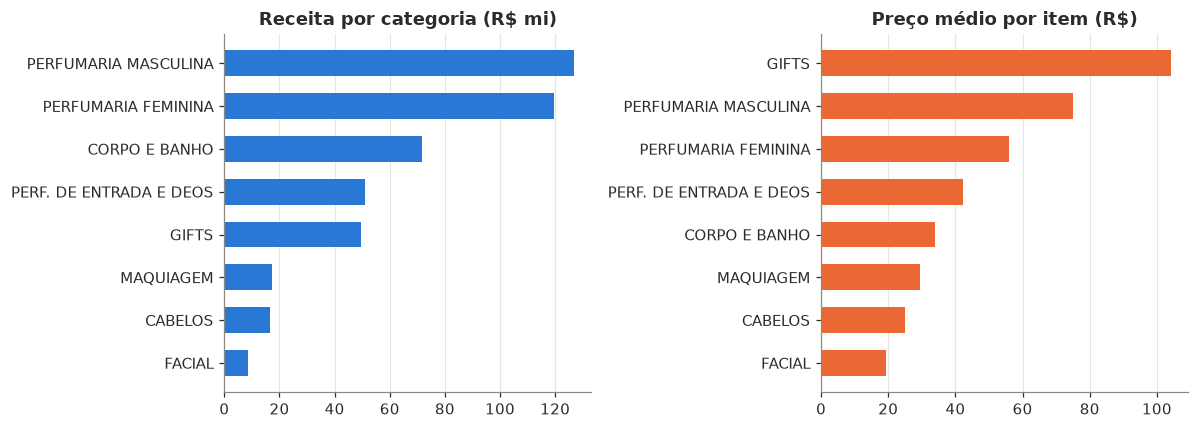

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
c = por_cat.drop('NÃO IDENTIFICADA', errors='ignore').sort_values('receita')
axs[0].barh(c.index, c.receita / 1e6, color=AZUL, height=.6); axs[0].set_title('Receita por categoria (R$ mi)'); axs[0].grid(axis='y', visible=False)
c2 = c.sort_values('preço_item')
axs[1].barh(c2.index, c2['preço_item'], color=LARANJA, height=.6); axs[1].set_title('Preço médio por item (R$)'); axs[1].grid(axis='y', visible=False)
plt.tight_layout(); salvar(fig, '02_categorias'); plt.show()
R['categorias'] = {k: {'receita_mi': round(v.receita / 1e6, 1), 'preco_item': round(v['preço_item'], 1), 'tx_desc': round(v['tx_desc_%'], 1)} for k, v in c.iterrows()}

## 4. Preço × desconto ao longo do tempo
O preço líquido por item cai quando a taxa de desconto sobe: o volume é "comprado" com promoção.

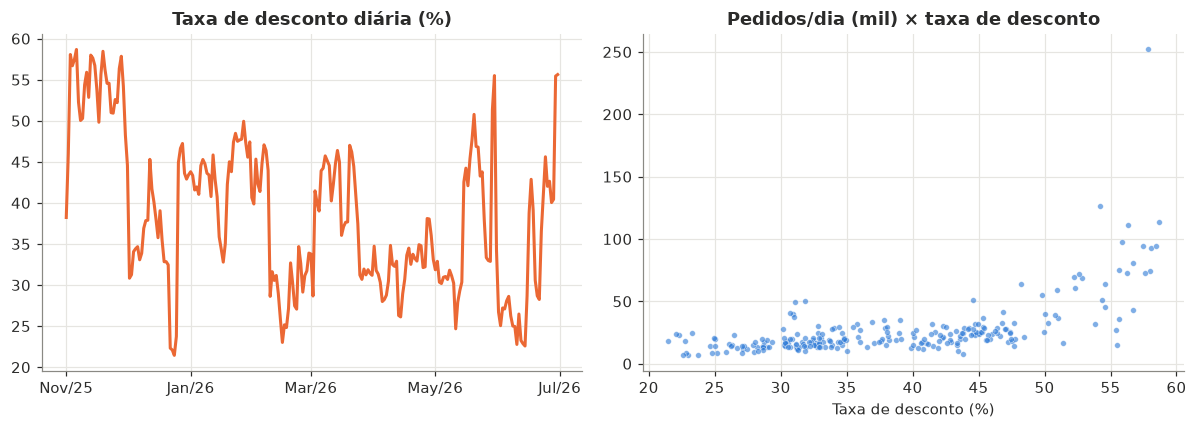

0.55 0.6 -0.65


In [8]:
dd = d.copy(); dd['preco_item'] = dd.receita_aprovada / dd.qt_material; dd['ticket'] = dd.receita_aprovada / dd.nr_pedidos
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(dd.index, 100 * dd.tx_desc, color=LARANJA); axs[0].set_title('Taxa de desconto diária (%)')
import matplotlib.dates as mdates
axs[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2)); axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axs[1].scatter(100 * dd.tx_desc, dd.nr_pedidos / 1e3, s=14, color=AZUL, alpha=.6, edgecolor='white', linewidth=.4)
axs[1].set_xlabel('Taxa de desconto (%)'); axs[1].set_title('Pedidos/dia (mil) × taxa de desconto')
plt.tight_layout(); salvar(fig, '03_desconto'); plt.show()
R['corr_receita_desconto'] = round(float(d.receita_aprovada.corr(d.tx_desc)), 2)
R['corr_pedidos_desconto'] = round(float(d.nr_pedidos.corr(d.tx_desc)), 2)
R['corr_ticket_desconto'] = round(float((d.receita_aprovada / d.nr_pedidos).corr(d.tx_desc)), 2)
print(R['corr_receita_desconto'], R['corr_pedidos_desconto'], R['corr_ticket_desconto'])

**Insight.** Dias de desconto alto trazem mais pedidos, mas com ticket menor: promoção move volume,
e a margem precisa ser olhada junto (a base não traz custo, então não medimos lucro).

## 5. Dia da semana
Para não confundir sazonalidade semanal com campanhas, usamos a **mediana** e excluímos novembro
(Black Friday) na leitura principal.

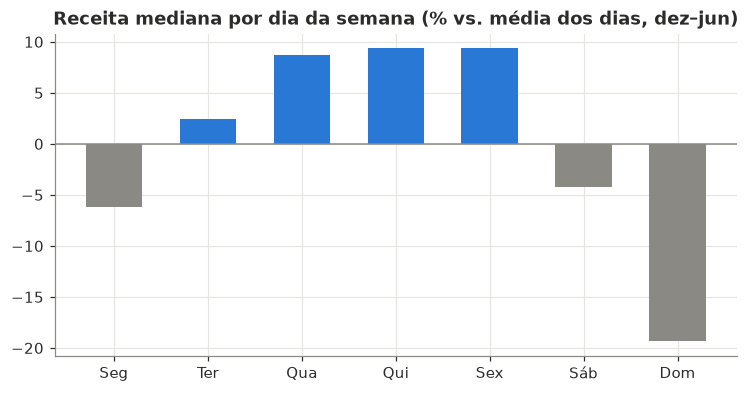

,receita_mediana,pedidos_mediana,indice_vs_media
Seg,1483013.69,19432.0,0.94
Ter,1620213.72,18761.0,1.02
Qua,1718520.61,18770.0,1.09
Qui,1729365.67,19904.0,1.09
Sex,1729468.26,20256.0,1.09
Sáb,1514063.83,17371.5,0.96
Dom,1275984.85,14427.0,0.81


In [9]:
dw = d.copy(); dw['dow'] = dw.index.dayofweek
base = dw[dw.index >= '2025-12-01']
s = base.groupby('dow').agg(receita_mediana=('receita_aprovada', 'median'), pedidos_mediana=('nr_pedidos', 'median'))
s['indice_vs_media'] = s.receita_mediana / s.receita_mediana.mean()
s.index = DIAS
fig, ax = plt.subplots(figsize=(8, 3.8))
cores = [AZUL if v >= 1 else CINZA for v in s.indice_vs_media]
ax.bar(s.index, 100 * (s.indice_vs_media - 1), color=cores, width=.6)
ax.set_title('Receita mediana por dia da semana (% vs. média dos dias, dez–jun)'); ax.axhline(0, color=CINZA, lw=1)
salvar(fig, '04_dia_semana'); plt.show()
R['dow_indice'] = s.indice_vs_media.round(2).to_dict()
s.round(2)

**Insight.** Quarta a sexta são os dias mais fortes (~9% acima da média), segunda e sábado ficam
ligeiramente abaixo e domingo é o mais fraco (~19% abaixo). O potencial de venda por dia
da semana deve ser lido como índice sobre a média, nunca como valor absoluto.

## 6. Comportamento ao longo do dia

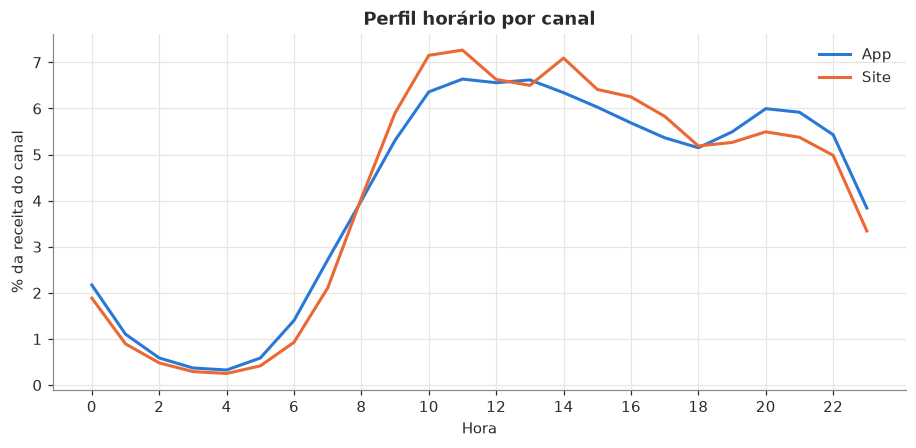

[11, 13, 12] 4.9 78.0


In [10]:
h = df.groupby(['canal', 'hora']).receita_aprovada.sum().unstack(0)
h = h / h.sum()
fig, ax = plt.subplots()
ax.plot(h.index, 100 * h['App'], color=AZUL, label='App'); ax.plot(h.index, 100 * h['Site'], color=LARANJA, label='Site')
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('Hora'); ax.set_ylabel('% da receita do canal'); ax.set_title('Perfil horário por canal'); ax.legend()
salvar(fig, '05_perfil_horario'); plt.show()
hh = df.groupby('hora').receita_aprovada.sum(); hh = hh / hh.sum()
R['pico_horas'] = [int(x) for x in hh.sort_values(ascending=False).index[:3]]
R['pct_madrugada_0_5'] = round(100 * hh.loc[0:5].sum(), 1)
R['pct_10_22'] = round(100 * hh.loc[10:22].sum(), 1)
print(R['pico_horas'], R['pct_madrugada_0_5'], R['pct_10_22'])

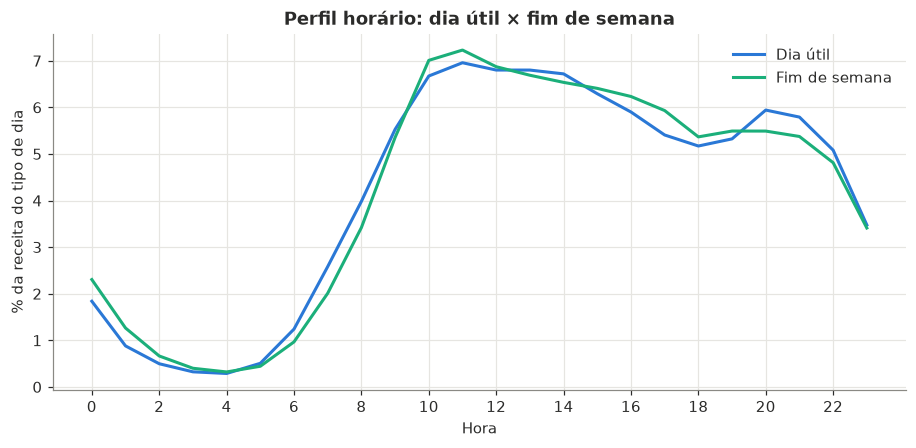

In [11]:
df['tipo_dia'] = np.where(df.dia_semana >= 5, 'Fim de semana', 'Dia útil')
hw = df[df.data >= '2025-12-01'].groupby(['tipo_dia', 'hora']).receita_aprovada.sum().unstack(0)
hw = hw / hw.sum()
fig, ax = plt.subplots()
ax.plot(hw.index, 100 * hw['Dia útil'], color=AZUL, label='Dia útil'); ax.plot(hw.index, 100 * hw['Fim de semana'], color=AQUA, label='Fim de semana')
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('Hora'); ax.set_ylabel('% da receita do tipo de dia'); ax.set_title('Perfil horário: dia útil × fim de semana'); ax.legend()
salvar(fig, '06_horario_tipo_dia'); plt.show()

**Insight.** A receita se concentra entre 10h e 22h, com platô entre 10h e 15h e uma leve
retomada à noite (19h–21h); a madrugada (0h–5h) responde por uma fatia pequena. A flutuação intradia
é estável o suficiente para usar o perfil horário como regra de pacing (acompanhar a meta do dia
hora a hora) e para posicionar disparos de CRM/mídia nos platôs.

## 7. Eventos atípicos: Black Friday e junho/2026

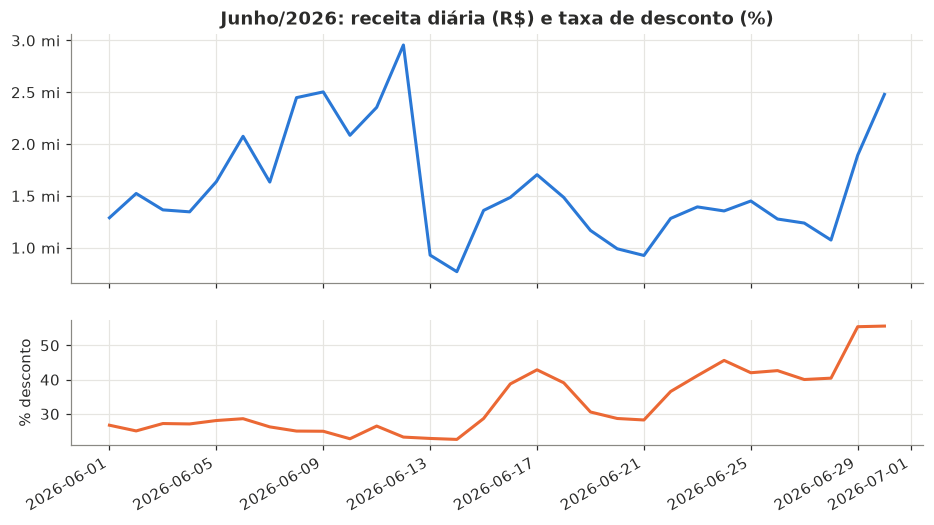

In [12]:
j = d['2026-06-01':]
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax.plot(j.index, j.receita_aprovada, color=AZUL)
ax.yaxis.set_major_formatter(FuncFormatter(milhoes)); ax.set_title('Junho/2026: receita diária (R$) e taxa de desconto (%)')
ax2.plot(j.index, 100 * j.tx_desc, color=LARANJA); ax2.set_ylabel('% desconto')
fig.autofmt_xdate(); salvar(fig, '07_junho'); plt.show()

Em 13–14/06 a receita cai de forma abrupta sem mudança na taxa de desconto. O que sabemos do calendário: 12/06 foi Dia dos Namorados
(sexta), 13/06 foi sábado e a estreia do Brasil na Copa do Mundo (Brasil × Marrocos, 19h de Brasília), e 14/06 foi domingo.
Testamos as explicações com os dados horários e por categoria:

In [13]:
h = df.groupby(['data', 'hora']).receita_aprovada.sum().unstack()
ref = h.loc[pd.to_datetime(['2026-06-06', '2026-06-20', '2026-06-27'])].mean()  # outros sábados de junho
r13 = (h.loc['2026-06-13'] / ref)
faixas = {'0–9h': r13.loc[0:9].mean(), '10–14h': r13.loc[10:14].mean(), '15–18h': r13.loc[15:18].mean(), '19–23h (jogo às 19h)': r13.loc[19:23].mean()}
print('Receita de sáb 13/06 ÷ média dos outros sábados de junho, por faixa horária:', {k: round(v, 2) for k, v in faixas.items()})
cat = df.groupby(['data', 'categoria']).receita_aprovada.sum().unstack()
queda = (cat.loc['2026-06-13'] / cat.loc['2026-06-08':'2026-06-12'].mean()).drop('NÃO IDENTIFICADA').sort_values()
print('Receita de 13/06 ÷ média de 8–12/06 por categoria:'); display(queda.round(2))
R['junho13_faixas'] = {k: round(float(v), 2) for k, v in faixas.items()}
R['junho13_categorias'] = queda.round(2).to_dict()

Receita de sáb 13/06 ÷ média dos outros sábados de junho, por faixa horária: {'0–9h': np.float64(0.74), '10–14h': np.float64(0.76), '15–18h': np.float64(0.49), '19–23h (jogo às 19h)': np.float64(0.45)}
Receita de 13/06 ÷ média de 8–12/06 por categoria:


categoria
GIFTS                      0.25
PERFUMARIA FEMININA        0.38
PERFUMARIA MASCULINA       0.39
PERF. DE ENTRADA E DEOS    0.42
MAQUIAGEM                  0.50
FACIAL                     0.51
CORPO E BANHO              0.51
CABELOS                    0.58
dtype: float64

**Leitura.** A queda é **ampla** (todas as categorias e canais e o dia inteiro), mas não uniforme:
- **Fim do pico de Namorados:** GIFTS despenca para ~25% do nível de 8–12/06, bem mais que as demais; é o padrão de demanda de presente que acaba no dia seguinte à data.
- **Fim de semana:** sábado e domingo já são mais fracos, mas isso explica só parte (domingo ≈ −19%).
- **Copa:** a manhã já está ~25% abaixo do usual, mas a queda quase dobra a partir das 15h (~50–55% abaixo até a noite, quando o jogo começou às 19h), compatível com efeito do jogo somado aos demais. Em 19/06 (sex., 21h30) a noite fica ~35–40% abaixo do usual; em 24/06 (qua., 19h) o efeito é pequeno.
- **Conclusão:** mais provável uma combinação de pós-Namorados + fim de semana + jogo do Brasil; com um único ano de dados não dá para separar os efeitos. Para modelar, seria preciso um calendário de eventos externos.

In [14]:
json.dump(R, open('../reports/resultados_eda.json', 'w'), ensure_ascii=False, indent=2, default=float)
print(json.dumps(R, ensure_ascii=False, indent=1, default=float)[:1500])

{
 "linhas": 89566,
 "pct_cat_corrompida_linhas": 6.0,
 "pct_cat_corrompida_receita": 6.0,
 "linhas_receita_nao_positiva": 4411,
 "receita_negativa_total": -21051829.386944577,
 "receita_negativa_pct": -4.3,
 "neg_mediana_item": [
  49.84,
  49.66
 ],
 "receita_abs_total": 532413485.54694456,
 "receita_abs_vs_liquida_pct": 8.6,
 "receita_total": 490309826.7730554,
 "receita_media_dia": 2026073.6643514684,
 "bf_receita": 12707522.618894326,
 "bf_multiplo": 7.5,
 "preco_item_geral": 49.545257495583954,
 "ticket_geral": 75.19057227160619,
 "tx_desc_geral": 43.64754712810411,
 "canal_receita_pct": {
  "App": 76.2,
  "Site": 23.8
 },
 "canal_ticket": {
  "App": 73.4,
  "Site": 81.5
 },
 "categorias": {
  "FACIAL": {
   "receita_mi": 8.6,
   "preco_item": 19.4,
   "tx_desc": 65.0
  },
  "CABELOS": {
   "receita_mi": 16.4,
   "preco_item": 25.1,
   "tx_desc": 43.6
  },
  "MAQUIAGEM": {
   "receita_mi": 17.3,
   "preco_item": 29.4,
   "tx_desc": 44.7
  },
  "GIFTS": {
   "receita_mi": 49.5,
  